# **TRIAL 1**



### **Objective**

- The objective of this experiment is to investigate whether `the
reported problem type alone` can predict the appropriate
`RESOLUTION_CATEGORY`.

- This experiment intentionally does **not** use KPI measurements.

- The purpose is to establish a baseline that later experiments
can improve upon.

### **Research Question**

> How good can the resolution category of a network ticket
> be predicted using only the reported problem group?


### Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Load the files

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install openpyxl


In [4]:
import pandas as pd

file1 = "new Tickets.xlsx"
file2= "new KPIs_14 to 31 OCT processing.xlsx"

tickets_df = pd.read_excel(f'/content/drive/MyDrive/26/{file1}')
kpi_df = pd.read_excel(f'/content/drive/MyDrive/26/{file2}')



### Data Exploration

In [5]:
print("Shape:", tickets_df.shape)

print("\nColumns:")
print(tickets_df.columns.tolist())

print("\nData types:")
print(tickets_df.dtypes)

print("\nFirst 5 rows:")
display(tickets_df.head())

Shape: (713, 6)

Columns:
['SITE_ID', 'CREATE_DATE_FMT', 'PROBLEM DETAIL (group)', 'RESOLUTION', 'RESOLUTION_CATEGORY', 'TICKET_STATUS']

Data types:
SITE_ID                           object
CREATE_DATE_FMT           datetime64[ns]
PROBLEM DETAIL (group)            object
RESOLUTION                        object
RESOLUTION_CATEGORY               object
TICKET_STATUS                     object
dtype: object

First 5 rows:


,SITE_ID,CREATE_DATE_FMT,PROBLEM DETAIL (group),RESOLUTION,RESOLUTION_CATEGORY,TICKET_STATUS
0,ABC00003,2019-10-24 06:02:19,Dropped Call,Explain what neighbors were corrected,RAN Site Optimization (RAN),Closed
1,ABC00024,2019-10-16 17:07:39,Dropped Call,Explain what neighbors were corrected,RAN Site Optimization (RAN),Closed
2,ABC00027,2019-10-16 15:39:08,Dropped Call,Explain what neighbors were corrected,RAN Site Optimization (RAN),Closed
3,ABC00075,2019-10-16 15:38:57,Dropped Call,Explain what neighbors were corrected,RAN Site Optimization (RAN),Closed
4,ABC00082,2019-10-31 16:09:36,Dropped Call,Explain what neighbors were corrected,RAN Site Optimization (RAN),Closed


KPI DATA

In [ ]:
print("Shape:", kpi_df.shape)

print("\nColumns:")
print(kpi_df.columns.tolist())

print("\nData types:")
print(kpi_df.dtypes)

print("\nFirst 5 rows:")
display(kpi_df.head())

Shape: (664440, 18)

Columns:
['Month, Day, Year of Datetimelocal', 'Site', 'EUTRANCELL_NAME', 'Usid', 'BH_HPCCE_UTIL', 'DL_TP (Kbps)', 'DL_Volume (GByte)', 'Data_ACC_Fail%', 'Data_DCR#', 'Data_DCR%', 'Volte_ACC_Fail%', 'Volte_DCR% (woRRE)', 'Volte_Drop# (woRRE)', 'UL_RSSI (dB)', 'DUAC#', 'INTERF_HO_SR%', 'INTRAF_HO_SR%', 'RrcConnMax']

Data types:
Month, Day, Year of Datetimelocal    datetime64[ns]
Site                                         object
EUTRANCELL_NAME                              object
Usid                                          int64
BH_HPCCE_UTIL                               float64
DL_TP (Kbps)                                float64
DL_Volume (GByte)                           float64
Data_ACC_Fail%                              float64
Data_DCR#                                   float64
Data_DCR%                                   float64
Volte_ACC_Fail%                             float64
Volte_DCR% (woRRE)                          float64
Volte_Drop# (woRRE)      

,"Month, Day, Year of Datetimelocal",Site,EUTRANCELL_NAME,Usid,BH_HPCCE_UTIL,DL_TP (Kbps),DL_Volume (GByte),Data_ACC_Fail%,Data_DCR#,Data_DCR%,Volte_ACC_Fail%,Volte_DCR% (woRRE),Volte_Drop# (woRRE),UL_RSSI (dB),DUAC#,INTERF_HO_SR%,INTRAF_HO_SR%,RrcConnMax
0,2019-10-14,ABC00001,ABC00001_2R_1_DB,156029,3.0,NaN,0.0,NaN,0.0,0.0,NaN,NaN,0.0,-119.0,0.0,NaN,NaN,1.0
1,2019-10-14,ABC00001,ABC00001_2S_1_DB,156029,3.0,214000.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,-119.0,0.0,100.0,NaN,1.0
2,2019-10-14,ABC00001,ABC00001_2T_1_DB,156029,3.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,-119.0,0.0,NaN,NaN,0.0
3,2019-10-14,ABC00001,ABC00001_7R_1_DB,156029,3.0,25629.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,-119.0,0.0,100.0,NaN,2.0
4,2019-10-14,ABC00001,ABC00001_7S_1_DB,156029,3.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,-118.0,0.0,NaN,100.0,1.0


In [6]:
def clean_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.strip()
        .str.upper()
        .str.replace(" ", "_", regex=False)
        .str.replace("%", "PCT", regex=False)
        .str.replace("#", "NUM", regex=False)
        .str.replace(",", "_", regex=False)
    )

    return df


In [7]:
tickets_df = clean_columns(tickets_df)
kpi_df = clean_columns(kpi_df)

print("Tickets columns:")
print(tickets_df.columns.tolist())

print("\nKPI columns:")
print(kpi_df.columns.tolist())

Tickets columns:
['SITE_ID', 'CREATE_DATE_FMT', 'PROBLEM_DETAIL_(GROUP)', 'RESOLUTION', 'RESOLUTION_CATEGORY', 'TICKET_STATUS']

KPI columns:
['MONTH__DAY__YEAR_OF_DATETIMELOCAL', 'SITE', 'EUTRANCELL_NAME', 'USID', 'BH_HPCCE_UTIL', 'DL_TP_(KBPS)', 'DL_VOLUME_(GBYTE)', 'DATA_ACC_FAILPCT', 'DATA_DCRNUM', 'DATA_DCRPCT', 'VOLTE_ACC_FAILPCT', 'VOLTE_DCRPCT_(WORRE)', 'VOLTE_DROPNUM_(WORRE)', 'UL_RSSI_(DB)', 'DUACNUM', 'INTERF_HO_SRPCT', 'INTRAF_HO_SRPCT', 'RRCCONNMAX']


TICKET DATA QUALITY

In [8]:
print("\nMissing values:")
display(
    tickets_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("MISSING")
)

print("\nUnique values:")
display(
    tickets_df.nunique()
    .sort_values()
    .to_frame("UNIQUE_VALUES")
)


Missing values:


,MISSING
SITE_ID,0
CREATE_DATE_FMT,0
PROBLEM_DETAIL_(GROUP),0
RESOLUTION,0
RESOLUTION_CATEGORY,0
TICKET_STATUS,0



Unique values:


,UNIQUE_VALUES
TICKET_STATUS,1
PROBLEM_DETAIL_(GROUP),5
RESOLUTION_CATEGORY,6
RESOLUTION,8
SITE_ID,445
CREATE_DATE_FMT,654


In [9]:
target_col = "RESOLUTION_CATEGORY"

print("Target:", target_col)
print("Number of classes:", tickets_df[target_col].nunique())

target_counts = (
    tickets_df[target_col]
    .value_counts(dropna=False)
)

display(target_counts.to_frame("COUNT"))

Target: RESOLUTION_CATEGORY
Number of classes: 6


,COUNT
RESOLUTION_CATEGORY,
RAN Site Optimization (RAN),645
(RAN) SW - Reset,32
(FO-RAN) HW - Replace,14
(FO-RAN) HW - Reseat/Physical Reset,11
(FO-RAN) Maintenance / Project,6
(RAN) Maintenance / Project,5


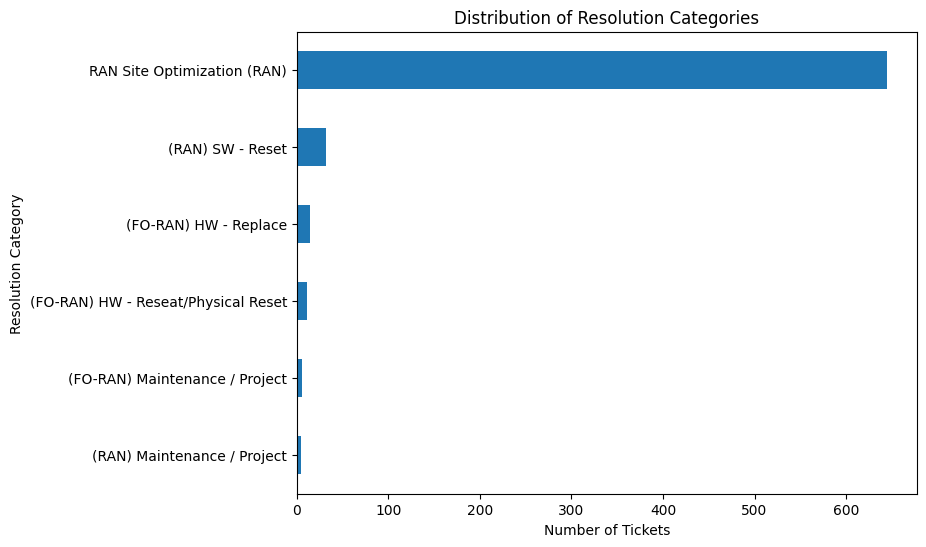

In [10]:
plt.figure(figsize=(8, 6))

target_counts.sort_values().plot(
    kind="barh"
)

plt.title("Distribution of Resolution Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Resolution Category")

plt.show()

In [11]:
target_distribution = (
    tickets_df[target_col]
    .value_counts()
    .to_frame("COUNT")
)

target_distribution["PERCENT"] = (
    target_distribution["COUNT"]
    / len(tickets_df)
    * 100
)


display(
    target_distribution.round(2)
)

,COUNT,PERCENT
RESOLUTION_CATEGORY,,
RAN Site Optimization (RAN),645,90.46
(RAN) SW - Reset,32,4.49
(FO-RAN) HW - Replace,14,1.96
(FO-RAN) HW - Reseat/Physical Reset,11,1.54
(FO-RAN) Maintenance / Project,6,0.84
(RAN) Maintenance / Project,5,0.70


In [12]:
problem_col = "PROBLEM_DETAIL_(GROUP)"

print("Number of problem groups:")
print(tickets_df[problem_col].nunique())

print("\nProblem distribution:")

problem_counts = (
    tickets_df[problem_col]
    .value_counts(dropna=False)
)

display(problem_counts.to_frame("COUNT"))

Number of problem groups:
5

Problem distribution:


,COUNT
PROBLEM_DETAIL_(GROUP),
Dropped Call,536
Blocked Call,145
Link Failure,13
SMART_SECTORS_OOS_ELTE,10
HW Fault,9


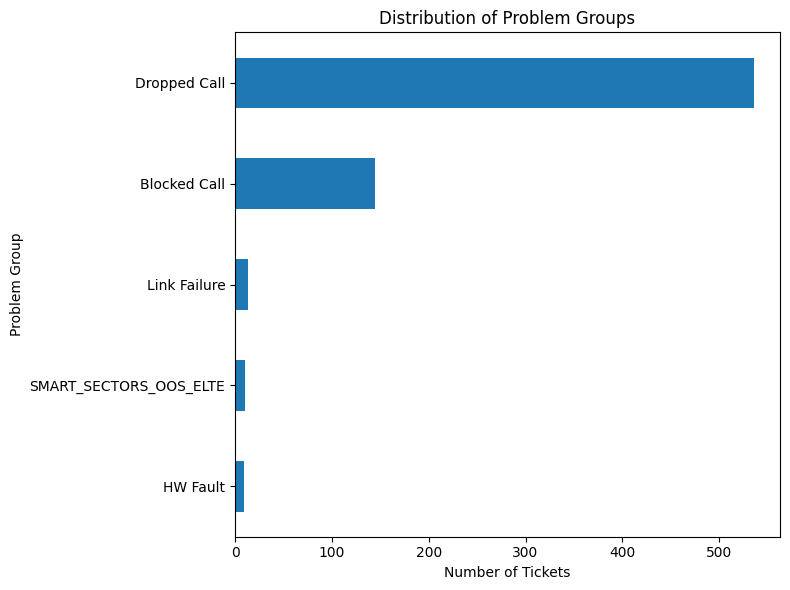

In [13]:
plt.figure(figsize=(8, 6))

problem_counts.sort_values().plot(
    kind="barh"
)

plt.title("Distribution of Problem Groups")
plt.xlabel("Number of Tickets")
plt.ylabel("Problem Group")

plt.tight_layout()
plt.show()

In [14]:
problem_resolution_pct = (
    pd.crosstab(
        tickets_df[problem_col],
        tickets_df[target_col],
        normalize="index"
    ) * 100
)

display(
    problem_resolution_pct.round(1)
)

RESOLUTION_CATEGORY,(FO-RAN) HW - Replace,(FO-RAN) HW - Reseat/Physical Reset,(FO-RAN) Maintenance / Project,(RAN) Maintenance / Project,(RAN) SW - Reset,RAN Site Optimization (RAN)
PROBLEM_DETAIL_(GROUP),,,,,,
Blocked Call,0.0,0.0,0.0,0.0,9.0,91.0
Dropped Call,0.0,0.2,0.6,0.0,3.5,95.7
HW Fault,44.4,44.4,0.0,11.1,0.0,0.0
Link Failure,38.5,30.8,15.4,15.4,0.0,0.0
SMART_SECTORS_OOS_ELTE,50.0,20.0,10.0,20.0,0.0,0.0


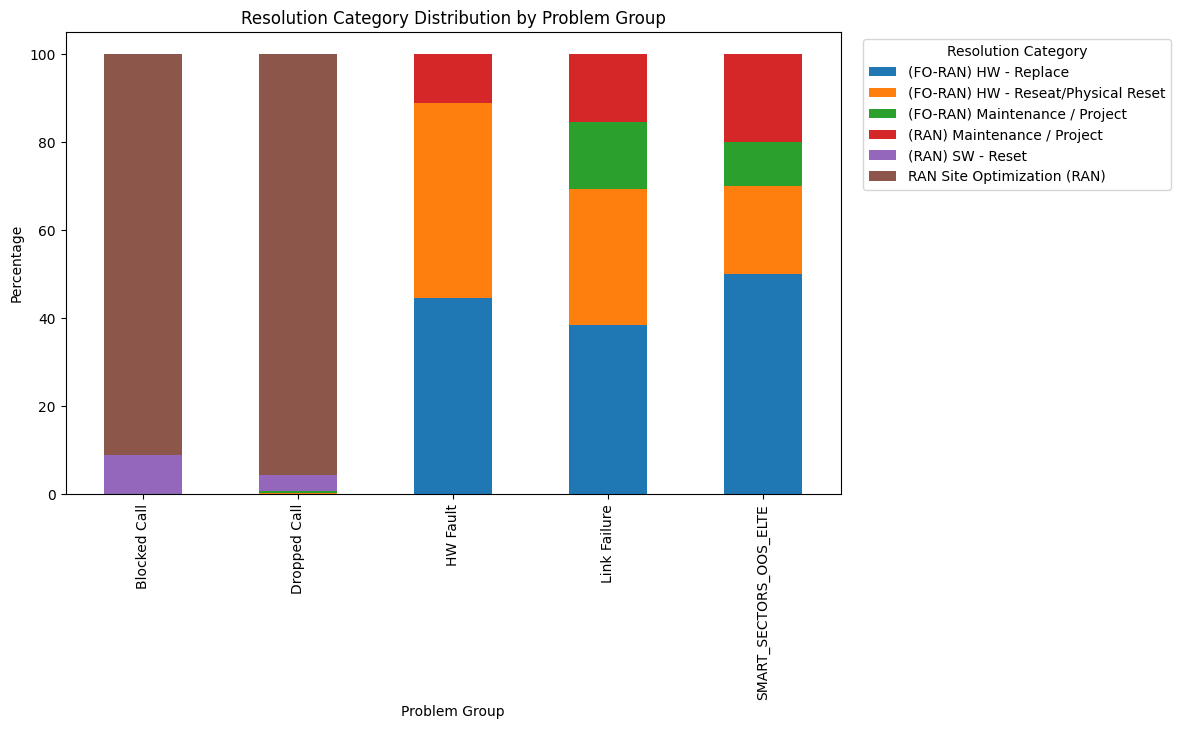

In [15]:
problem_resolution_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Resolution Category Distribution by Problem Group"
)

plt.xlabel("Problem Group")
plt.ylabel("Percentage")


plt.legend(
    title="Resolution Category",
    bbox_to_anchor=(1.02, 1)
)

plt.show()

In [16]:
problem_counts = pd.crosstab(
    tickets_df[problem_col],
    tickets_df[target_col]
)
problem_counts


RESOLUTION_CATEGORY,(FO-RAN) HW - Replace,(FO-RAN) HW - Reseat/Physical Reset,(FO-RAN) Maintenance / Project,(RAN) Maintenance / Project,(RAN) SW - Reset,RAN Site Optimization (RAN)
PROBLEM_DETAIL_(GROUP),,,,,,
Blocked Call,0,0,0,0,13,132
Dropped Call,0,1,3,0,19,513
HW Fault,4,4,0,1,0,0
Link Failure,5,4,2,2,0,0
SMART_SECTORS_OOS_ELTE,5,2,1,2,0,0


In [17]:
problem_purity = (
    problem_counts.max(axis=1)
    / problem_counts.sum(axis=1)
)
problem_purity

,0
PROBLEM_DETAIL_(GROUP),
Blocked Call,0.910345
Dropped Call,0.957090
HW Fault,0.444444
Link Failure,0.384615
SMART_SECTORS_OOS_ELTE,0.500000


In [18]:
problem_purity = (
    problem_purity
    .sort_values(ascending=False)
)
problem_purity

,0
PROBLEM_DETAIL_(GROUP),
Dropped Call,0.957090
Blocked Call,0.910345
SMART_SECTORS_OOS_ELTE,0.500000
HW Fault,0.444444
Link Failure,0.384615


In [19]:
display(
    problem_purity.to_frame("PURITY").round(3)
)

,PURITY
PROBLEM_DETAIL_(GROUP),
Dropped Call,0.957
Blocked Call,0.910
SMART_SECTORS_OOS_ELTE,0.500
HW Fault,0.444
Link Failure,0.385


In [20]:
print("Unique sites:")
print(tickets_df["SITE_ID"].nunique())

site_ticket_counts = (
    tickets_df["SITE_ID"]
    .value_counts()
)
site_ticket_counts

Unique sites:
445


,count
SITE_ID,
ABD01125,10
ABD04106,6
ABC02862,6
ABC01880,5
ABD01710,5
...,...
ABD04868,1
ABD04874,1
ABD04658,1


In [21]:

print("\nTickets per site:")
display(site_ticket_counts.describe())

print("\nSites with multiple tickets:")
display(
    site_ticket_counts[
        site_ticket_counts > 1
    ].head(20)
)


Tickets per site:


,count
count,445.000000
mean,1.602247
std,1.025132
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,10.000000



Sites with multiple tickets:


,count
SITE_ID,
ABD01125,10
ABD04106,6
ABC02862,6
ABC01880,5
ABD01710,5
ABD04095,5
ABC02430,5
ABD01724,5
ABD01809,5


In [22]:
trial1_df = tickets_df[
    [
        "SITE_ID",
        problem_col,
        target_col
    ]
].copy()

trial1_df = trial1_df.dropna(
    subset=[problem_col, target_col]
)

print("Trial 1 dataset shape:")
print(trial1_df.shape)

display(trial1_df.head())

Trial 1 dataset shape:
(713, 3)


,SITE_ID,PROBLEM_DETAIL_(GROUP),RESOLUTION_CATEGORY
0,ABC00003,Dropped Call,RAN Site Optimization (RAN)
1,ABC00024,Dropped Call,RAN Site Optimization (RAN)
2,ABC00027,Dropped Call,RAN Site Optimization (RAN)
3,ABC00075,Dropped Call,RAN Site Optimization (RAN)
4,ABC00082,Dropped Call,RAN Site Optimization (RAN)


In [24]:
from sklearn.model_selection import train_test_split

X = trial1_df[[problem_col]].copy()
y = trial1_df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))



Training rows: 570
Testing rows: 143


In [26]:
print("Training target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())


Training target distribution:


,count
RESOLUTION_CATEGORY,
RAN Site Optimization (RAN),516
(RAN) SW - Reset,25
(FO-RAN) HW - Replace,11
(FO-RAN) HW - Reseat/Physical Reset,9
(FO-RAN) Maintenance / Project,5
(RAN) Maintenance / Project,4



Testing target distribution:


,count
RESOLUTION_CATEGORY,
RAN Site Optimization (RAN),129
(RAN) SW - Reset,7
(FO-RAN) HW - Replace,3
(FO-RAN) HW - Reseat/Physical Reset,2
(RAN) Maintenance / Project,1
(FO-RAN) Maintenance / Project,1


In [27]:
problem_preprocessor = ColumnTransformer(
    transformers=[
        (
            "problem",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            [problem_col]
        )
    ]
)

trial1_model = Pipeline(
    steps=[
        (
            "preprocessor",
            problem_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [28]:
trial1_model.fit(
    X_train,
    y_train
)

y_pred = trial1_model.predict(X_test)

print("Trial 1 model trained successfully.")

Trial 1 model trained successfully.


In [29]:
trial1_accuracy = accuracy_score(
    y_test,
    y_pred
)

trial1_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

trial1_macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

trial1_weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("TRIAL 1 — PROBLEM ONLY")

print("Accuracy:", trial1_accuracy)
print("Balanced Accuracy:", trial1_balanced_accuracy)
print("Macro F1:", trial1_macro_f1)
print("Weighted F1:", trial1_weighted_f1)

TRIAL 1 — PROBLEM ONLY
Accuracy: 0.7272727272727273
Balanced Accuracy: 0.38325950535252856
Macro F1: 0.3124057165541882
Weighted F1: 0.789333929270412


In [30]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                                     precision    recall  f1-score   support

              (FO-RAN) HW - Replace       0.50      0.33      0.40         3
(FO-RAN) HW - Reseat/Physical Reset       0.33      0.50      0.40         2
     (FO-RAN) Maintenance / Project       0.00      0.00      0.00         1
        (RAN) Maintenance / Project       0.00      0.00      0.00         1
                   (RAN) SW - Reset       0.14      0.71      0.23         7
        RAN Site Optimization (RAN)       0.97      0.75      0.85       129

                           accuracy                           0.73       143
                          macro avg       0.32      0.38      0.31       143
                       weighted avg       0.90      0.73      0.79       143



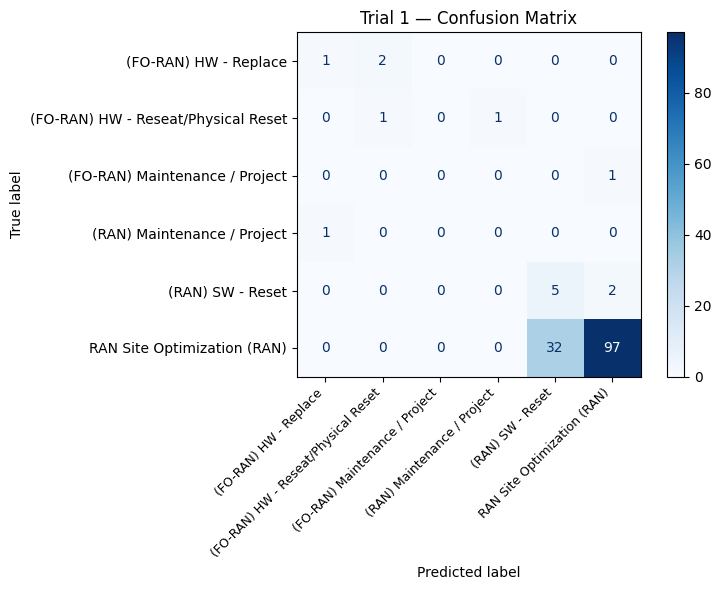

In [31]:
labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap='Blues',
)

ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right",
    fontsize=9
)

plt.title("Trial 1 — Confusion Matrix")

plt.tight_layout()
plt.show()

In [33]:
majority_class = y_train.mode()[0]

baseline_pred = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_pred
)

baseline_macro_f1 = f1_score(
    y_test,
    baseline_pred,
    average="macro"
)

print("MAJORITY BASELINE:\n")

print("Majority class:", majority_class)
print("Accuracy:", baseline_accuracy)
print("Balanced Accuracy:", baseline_balanced_accuracy)
print("Macro F1:", baseline_macro_f1)


MAJORITY BASELINE:

Majority class: RAN Site Optimization (RAN)
Accuracy: 0.9020979020979021
Balanced Accuracy: 0.16666666666666666
Macro F1: 0.15808823529411764


In [37]:
# SAVE TRIAL 1 MODEL + RESULTS

import os
import joblib

trial1_folder = "/content/drive/MyDrive/26/model_trials/trial_1"

os.makedirs(trial1_folder, exist_ok=True)

print("Saving Trial 1 to:")
print(trial1_folder)

Saving Trial 1 to:
/content/drive/MyDrive/26/model_trials/trial_1


In [38]:
model_path = os.path.join(
    trial1_folder,
    "trial_1_problem_only_model.joblib"
)

joblib.dump(
    trial1_model,
    model_path
)

print("Model saved:")
print(model_path)

Model saved:
/content/drive/MyDrive/26/model_trials/trial_1/trial_1_problem_only_model.joblib


FEATURE IMPORTANCE: TRIAL 1


--- TRIAL 1 FEATURE IMPORTANCE ---


,feature,coefficient,abs_coefficient
1,PROBLEM_DETAIL_(GROUP)_Dropped Call,-2.061667,2.061667
4,PROBLEM_DETAIL_(GROUP)_SMART_SECTORS_OOS_ELTE,1.167044,1.167044
0,PROBLEM_DETAIL_(GROUP)_Blocked Call,-1.122462,1.122462
2,PROBLEM_DETAIL_(GROUP)_HW Fault,1.023320,1.023320
3,PROBLEM_DETAIL_(GROUP)_Link Failure,1.003468,1.003468


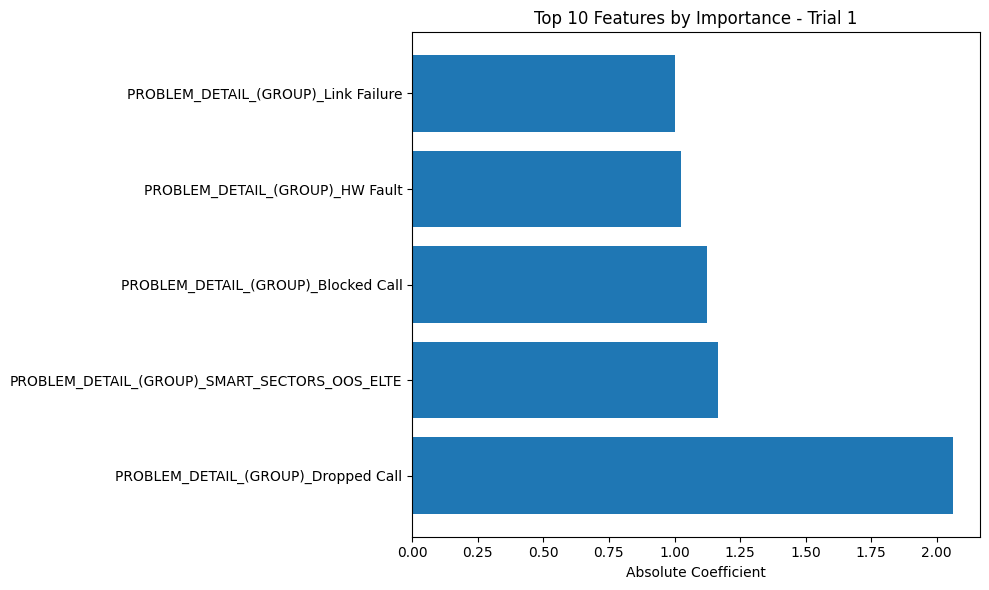


--- TRIAL 1 PREDICTION CONFIDENCE ---
Average confidence: 0.438
Min confidence: 0.289
Max confidence: 0.571

Low confidence predictions (<0.7): 143 out of 143


,Actual,Predicted,Confidence,Correct
0,(RAN) SW - Reset,(RAN) SW - Reset,0.570867,True
1,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.392775,True
2,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.392775,True
3,RAN Site Optimization (RAN),(RAN) SW - Reset,0.570867,False
4,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.392775,True
5,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.392775,True
6,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.392775,True
7,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.392775,True
8,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.392775,True
9,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.392775,True


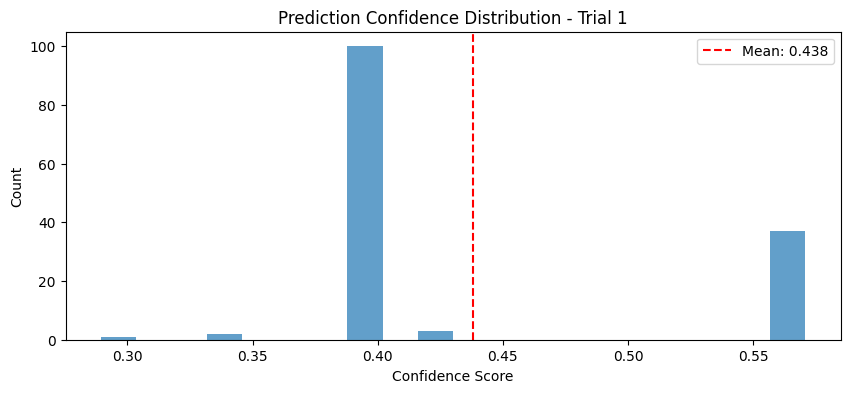

In [51]:
preprocessor = trial1_model.named_steps['preprocessor']
onehot_encoder = preprocessor.named_transformers_['problem'].named_steps['onehot']
feature_names = onehot_encoder.get_feature_names_out([problem_col])

classifier = trial1_model.named_steps['classifier']
coefficients = classifier.coef_[0]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("\n--- TRIAL 1 FEATURE IMPORTANCE ---")
display(importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'].head(10), importance_df['abs_coefficient'].head(10))
plt.xlabel('Absolute Coefficient')
plt.title('Top 10 Features by Importance - Trial 1')
plt.tight_layout()
plt.show()


y_pred_proba = trial1_model.predict_proba(X_test)

confidence_scores = np.max(y_pred_proba, axis=1)
predicted_classes = trial1_model.predict(X_test)

confidence_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predicted_classes,
    'Confidence': confidence_scores,
    'Correct': y_test.values == predicted_classes
})

print("\n--- TRIAL 1 PREDICTION CONFIDENCE ---")
print(f"Average confidence: {confidence_scores.mean():.3f}")
print(f"Min confidence: {confidence_scores.min():.3f}")
print(f"Max confidence: {confidence_scores.max():.3f}")

low_confidence = confidence_df[confidence_df['Confidence'] < 0.7]
print(f"\nLow confidence predictions (<0.7): {len(low_confidence)} out of {len(confidence_df)}")
display(low_confidence.head(10))

plt.figure(figsize=(10, 4))
plt.hist(confidence_scores, bins=20, alpha=0.7)
plt.axvline(confidence_scores.mean(), color='red', linestyle='--', label=f'Mean: {confidence_scores.mean():.3f}')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution - Trial 1')
plt.legend()
plt.show()

SAVE TRIAL 1 FEATURE IMPORTANCE & CONFIDENCE

In [52]:

importance_df.to_csv(os.path.join(trial1_folder, "trial_1_feature_importance.csv"), index=False)

confidence_df.to_csv(os.path.join(trial1_folder, "trial_1_prediction_confidence.csv"), index=False)

confidence_summary_t1 = pd.DataFrame({
    'Metric': ['Mean Confidence', 'Min Confidence', 'Max Confidence', 'Low Confidence Count'],
    'Value': [
        confidence_scores.mean(),
        confidence_scores.min(),
        confidence_scores.max(),
        len(confidence_df[confidence_df['Confidence'] < 0.7])
    ]
})
confidence_summary_t1.to_csv(os.path.join(trial1_folder, "trial_1_confidence_summary.csv"), index=False)

plt.figure(figsize=(10, 4))
plt.hist(confidence_scores, bins=20, alpha=0.7)
plt.axvline(confidence_scores.mean(), color='red', linestyle='--', label=f'Mean: {confidence_scores.mean():.3f}')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution - Trial 1')
plt.legend()
plt.savefig(os.path.join(trial1_folder, "trial_1_confidence_distribution.png"), dpi=150, bbox_inches='tight')
plt.close()

print(f"Trial 1 feature importance and confidence results saved to: {trial1_folder}")

Trial 1 feature importance and confidence results saved to: /content/drive/MyDrive/26/model_trials/trial_1


# **TRIAL 2 — KPI Measures Only**


### **Objective**

- The objective of this experiment is to investigate whether `KPI
measurements alone` can predict the appropriate
`RESOLUTION_CATEGORY`.

- This experiment intentionally does **not** use the reported
problem group.

- The purpose is to compare against the Trial 1 baseline and see
whether KPI data carries more (or less) predictive signal than
the problem group alone.


### **Research Question**

> How accurately can the resolution category of a network ticket
> be predicted using only KPI measurements?


### Merge Tickets with KPI Data

In [53]:
kpi_merge_key = "SITE"

kpi_numeric_cols = kpi_df.select_dtypes(include="number").columns.tolist()

kpi_site_level = (
    kpi_df
    .groupby(kpi_merge_key)[kpi_numeric_cols]
    .mean()
    .reset_index()
)

print("Site-level KPI shape:", kpi_site_level.shape)
display(kpi_site_level.head())

trial2_base = tickets_df[["SITE_ID", target_col]].copy()

trial2_df = trial2_base.merge(
    kpi_site_level,
    left_on="SITE_ID",
    right_on=kpi_merge_key,
    how="inner"
)

print("Trial 2 merged dataset shape:")
print(trial2_df.shape)

display(trial2_df.head())


Site-level KPI shape: (5101, 16)


,SITE,USID,BH_HPCCE_UTIL,DL_TP_(KBPS),DL_VOLUME_(GBYTE),DATA_ACC_FAILPCT,DATA_DCRNUM,DATA_DCRPCT,VOLTE_ACC_FAILPCT,VOLTE_DCRPCT_(WORRE),VOLTE_DROPNUM_(WORRE),UL_RSSI_(DB),DUACNUM,INTERF_HO_SRPCT,INTRAF_HO_SRPCT,RRCCONNMAX
0,ABC00001,156029.0,3.925926,19505.847458,409.370370,0.000000,0.740741,0.087719,7.857143,0.000000,0.000000,-117.925926,0.0,99.921569,97.777778,4.888889
1,ABC00002,156029.0,3.361111,28291.462366,288.268519,0.271739,0.527778,0.279570,0.179487,0.000000,0.000000,-117.648148,0.0,99.348315,98.707865,3.638889
2,ABC00003,80973.0,7.768519,7692.685185,11113.277778,0.546296,59.916667,0.268519,0.601852,0.388889,0.583333,-114.685185,0.0,97.453704,98.861111,26.425926
3,ABC00004,80973.0,3.962963,25230.731481,78491.759259,0.000000,175.870370,0.000000,0.000000,0.046296,1.333333,-114.037037,0.0,82.907407,98.657407,100.277778
4,ABC00005,80973.0,3.777778,19889.083333,79423.138889,0.000000,95.370370,0.000000,0.000000,0.009259,0.314815,-113.435185,0.0,92.148148,99.787037,113.055556


Trial 2 merged dataset shape:
(713, 18)


,SITE_ID,RESOLUTION_CATEGORY,SITE,USID,BH_HPCCE_UTIL,DL_TP_(KBPS),DL_VOLUME_(GBYTE),DATA_ACC_FAILPCT,DATA_DCRNUM,DATA_DCRPCT,VOLTE_ACC_FAILPCT,VOLTE_DCRPCT_(WORRE),VOLTE_DROPNUM_(WORRE),UL_RSSI_(DB),DUACNUM,INTERF_HO_SRPCT,INTRAF_HO_SRPCT,RRCCONNMAX
0,ABC00003,RAN Site Optimization (RAN),ABC00003,80973.0,7.768519,7692.685185,11113.277778,0.546296,59.916667,0.268519,0.601852,0.388889,0.583333,-114.685185,0.000000,97.453704,98.861111,26.425926
1,ABC00024,RAN Site Optimization (RAN),ABC00024,159420.0,6.139344,30214.777778,33353.753086,0.370370,218.672840,0.783951,0.322981,1.333333,5.283951,-117.382716,0.000000,87.080247,81.623457,55.049383
2,ABC00027,RAN Site Optimization (RAN),ABC00027,139265.0,15.066667,14360.755556,81565.570370,0.170370,267.488889,0.277778,0.151852,0.348148,8.400000,-114.103704,0.166667,88.433333,98.100000,87.744444
3,ABC00075,RAN Site Optimization (RAN),ABC00075,159057.0,11.172840,19366.851852,55167.493827,0.030864,272.870370,0.407407,0.030864,1.209877,11.475309,-116.401235,0.382716,89.604938,98.987654,82.364198
4,ABC00082,RAN Site Optimization (RAN),ABC00082,128501.0,6.882353,15033.175000,4284.541667,1.000000,447.625000,2.375000,1.450000,14.125000,28.180556,-112.385714,0.000000,64.076923,85.825000,16.416667


### Select KPI Feature Columns

In [54]:
exclude_cols = ["SITE_ID", kpi_merge_key, target_col]

kpi_feature_cols = [
    c for c in trial2_df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(trial2_df[c])
]

print("KPI feature columns used in Trial 2:")
print(kpi_feature_cols)


KPI feature columns used in Trial 2:
['USID', 'BH_HPCCE_UTIL', 'DL_TP_(KBPS)', 'DL_VOLUME_(GBYTE)', 'DATA_ACC_FAILPCT', 'DATA_DCRNUM', 'DATA_DCRPCT', 'VOLTE_ACC_FAILPCT', 'VOLTE_DCRPCT_(WORRE)', 'VOLTE_DROPNUM_(WORRE)', 'UL_RSSI_(DB)', 'DUACNUM', 'INTERF_HO_SRPCT', 'INTRAF_HO_SRPCT', 'RRCCONNMAX']


In [55]:
trial2_df = trial2_df.dropna(subset=[target_col])

print("Trial 2 dataset shape after dropping missing targets:")
print(trial2_df.shape)


Trial 2 dataset shape after dropping missing targets:
(713, 18)


### Train / Test Split

In [56]:
from sklearn.model_selection import train_test_split

X2 = trial2_df[kpi_feature_cols].copy()
y2 = trial2_df[target_col].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

print("Training rows:", len(X2_train))
print("Testing rows:", len(X2_test))


Training rows: 570
Testing rows: 143


### Preprocessing (Two Variants: Imputed vs Raw-with-Native-Missing-Handling)

In [57]:
from sklearn.preprocessing import StandardScaler

# impute + scale — needed for models that CANNOT handle NaN
kpi_preprocessor_impute = ColumnTransformer(
    transformers=[
        (
            "kpi",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            kpi_feature_cols
        )
    ]
)

# handle missing values (CatBoost, LightGBM, HistGradientBoosting).
kpi_preprocessor_raw = ColumnTransformer(
    transformers=[
        ("kpi", "passthrough", kpi_feature_cols)
    ]
)


### Install/Import CatBoost & LightGBM

In [58]:
!pip install catboost lightgbm -q


In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


### Define Candidate Models

- Models needing imputed/scaled input: `Logistic Regression`, `SVM`,
  `Random Forest`
- Models with **native missing-value handling** (fed raw,
  un-imputed KPI columns): `Decision Tree` (sklearn, via its own
  handling in recent versions is limited — kept in the imputed
  group below unless your sklearn version supports NaN splits),
  `HistGradientBoosting`, `CatBoost`, `LightGBM`


In [60]:
candidate_models_trial2 = {
    "Logistic Regression": (kpi_preprocessor_impute, LogisticRegression(max_iter=1000)),
    "SVM (RBF)": (kpi_preprocessor_impute, SVC(kernel="rbf", random_state=42)),
    "Random Forest": (kpi_preprocessor_impute, RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    )),
    "Decision Tree": (kpi_preprocessor_impute, DecisionTreeClassifier(
        random_state=42
    )),

    # Native missing-value handling: no imputation needed
    "HistGradientBoosting": (kpi_preprocessor_raw, HistGradientBoostingClassifier(
        random_state=42
    )),
    "CatBoost": (kpi_preprocessor_raw, CatBoostClassifier(
        random_state=42,
        verbose=0
    )),
    "LightGBM": (kpi_preprocessor_raw, LGBMClassifier(
        random_state=42,
        verbose=-1
    ))
}


### Train & Evaluate Each Model

In [61]:
trial2_results = []
trial2_fitted_models = {}

for model_name, (preprocessor, estimator) in candidate_models_trial2.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", estimator)
    ])

    pipeline.fit(X2_train, y2_train)
    preds = pipeline.predict(X2_test)

    trial2_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y2_test, preds),
        "Balanced Accuracy": balanced_accuracy_score(y2_test, preds),
        "Macro F1": f1_score(y2_test, preds, average="macro"),
        "Weighted F1": f1_score(y2_test, preds, average="weighted")
    })

    trial2_fitted_models[model_name] = pipeline

    print(f"{model_name} done.")

trial2_results_df = pd.DataFrame(trial2_results).set_index("Model")
display(trial2_results_df.round(3))


Logistic Regression done.
SVM (RBF) done.
Random Forest done.
Decision Tree done.
HistGradientBoosting done.
CatBoost done.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM done.


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
Model,,,,
Logistic Regression,0.895,0.165,0.157,0.852
SVM (RBF),0.902,0.167,0.158,0.856
Random Forest,0.909,0.222,0.242,0.869
Decision Tree,0.874,0.216,0.223,0.853
HistGradientBoosting,0.902,0.221,0.225,0.864
CatBoost,0.909,0.222,0.242,0.869
LightGBM,0.909,0.222,0.242,0.869


### Compare Models Visually

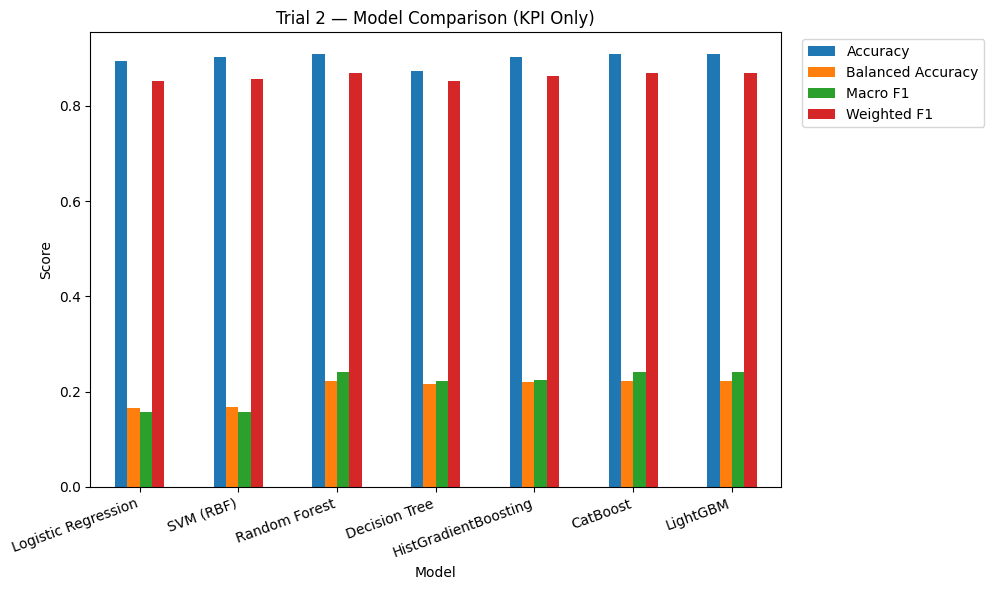

In [62]:
trial2_results_df[["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Trial 2 — Model Comparison (KPI Only)")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


### Pick the Best Model

In [63]:
best_model_name_2 = trial2_results_df["Balanced Accuracy"].idxmax()
best_model_2 = trial2_fitted_models[best_model_name_2]

print("Best model by Balanced Accuracy:", best_model_name_2)
display(trial2_results_df.loc[[best_model_name_2]].round(3))

trial2_accuracy = trial2_results_df.loc[best_model_name_2, "Accuracy"]
trial2_balanced_accuracy = trial2_results_df.loc[best_model_name_2, "Balanced Accuracy"]
trial2_macro_f1 = trial2_results_df.loc[best_model_name_2, "Macro F1"]
trial2_weighted_f1 = trial2_results_df.loc[best_model_name_2, "Weighted F1"]
trial2_model = best_model_2


Best model by Balanced Accuracy: Random Forest


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
Model,,,,
Random Forest,0.909,0.222,0.242,0.869


In [64]:
y2_pred_best = best_model_2.predict(X2_test)

print(
    classification_report(
        y2_test,
        y2_pred_best,
        zero_division=0
    )
)


                                     precision    recall  f1-score   support

              (FO-RAN) HW - Replace       1.00      0.33      0.50         3
(FO-RAN) HW - Reseat/Physical Reset       0.00      0.00      0.00         2
     (FO-RAN) Maintenance / Project       0.00      0.00      0.00         1
        (RAN) Maintenance / Project       0.00      0.00      0.00         1
                   (RAN) SW - Reset       0.00      0.00      0.00         7
        RAN Site Optimization (RAN)       0.91      1.00      0.95       129

                           accuracy                           0.91       143
                          macro avg       0.32      0.22      0.24       143
                       weighted avg       0.84      0.91      0.87       143



In [87]:
X2_test

,USID,BH_HPCCE_UTIL,DL_TP_(KBPS),DL_VOLUME_(GBYTE),DATA_ACC_FAILPCT,DATA_DCRNUM,DATA_DCRPCT,VOLTE_ACC_FAILPCT,VOLTE_DCRPCT_(WORRE),VOLTE_DROPNUM_(WORRE),UL_RSSI_(DB),DUACNUM,INTERF_HO_SRPCT,INTRAF_HO_SRPCT,RRCCONNMAX
701,15985.0,18.132867,6301.319444,133091.312500,0.013889,978.319444,0.833333,0.062500,1.756944,38.868056,-116.590278,0.000000,63.826389,96.055556,176.125000
622,82549.0,23.141975,10095.919753,85640.907407,0.018519,898.864198,0.302469,0.043210,1.623457,37.759259,-117.240741,0.265432,77.672840,97.283951,149.413580
563,9528.0,8.638889,21770.791667,38576.782407,0.578704,661.185185,2.365741,0.458333,3.481481,15.425926,-118.212963,3.115741,85.722222,96.296296,53.861111
463,100654.0,12.728395,12960.061728,74631.037037,0.104938,1024.419753,0.685185,0.200000,2.734568,31.370370,-117.104938,0.407407,78.666667,94.753086,109.413580
202,82525.0,12.855556,24613.333333,64876.407407,0.098039,847.731481,0.715686,0.274510,2.480392,29.592593,-117.490196,0.000000,82.764706,94.372549,88.444444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,97757.0,17.745370,12410.143519,80132.759259,0.194444,172.902778,0.324074,0.226852,0.879630,6.634259,-116.074074,0.000000,98.138889,97.787037,66.736111
603,26349.0,8.314815,16210.503704,31843.244444,0.318519,293.362963,0.936803,0.270588,2.138996,10.718519,-116.781481,2.300000,86.809701,95.818519,42.633333
420,170268.0,12.019608,18920.500000,17823.015152,1.008333,1250.992424,2.000000,1.116667,5.916667,72.401515,-115.325581,0.000000,93.991667,95.983607,51.083333
627,50890.0,10.074074,26900.441860,15515.250000,1.840659,107.930556,2.653631,0.419753,0.666667,2.189815,-115.462963,0.222222,97.543860,97.895706,26.740741


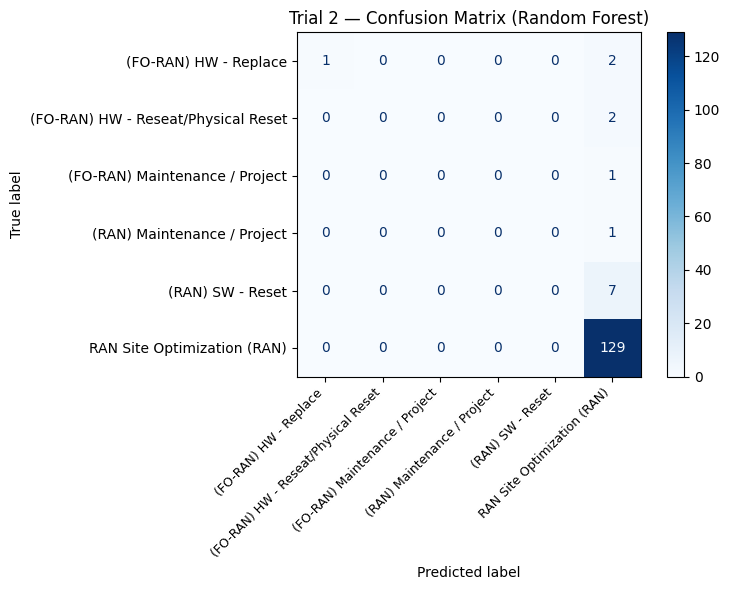

In [65]:
labels2 = sorted(y2.unique())

cm2 = confusion_matrix(
    y2_test,
    y2_pred_best,
    labels=labels2
)

fig, ax = plt.subplots(figsize=(8, 6))

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=labels2
)

disp2.plot(ax=ax, cmap='Blues')

ax.set_xticklabels(labels2, rotation=45, ha="right", fontsize=9)

plt.title(f"Trial 2 — Confusion Matrix ({best_model_name_2})")

plt.tight_layout()
plt.show()


### Compare Against Trial 1

In [66]:
comparison = pd.DataFrame({
    "Trial 1 (Problem Only)": [
        trial1_accuracy,
        trial1_balanced_accuracy,
        trial1_macro_f1,
        trial1_weighted_f1
    ],
    f"Trial 2 ({best_model_name_2})": [
        trial2_accuracy,
        trial2_balanced_accuracy,
        trial2_macro_f1,
        trial2_weighted_f1
    ]
}, index=["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"])

display(comparison.round(3))


,Trial 1 (Problem Only),Trial 2 (Random Forest)
Accuracy,0.727,0.909
Balanced Accuracy,0.383,0.222
Macro F1,0.312,0.242
Weighted F1,0.789,0.869


### Save Best Trial 2 Model

In [67]:
import os
import joblib

trial2_folder = "/content/drive/MyDrive/26/model_trials/trial_2"
os.makedirs(trial2_folder, exist_ok=True)

safe_name_2 = best_model_name_2.lower().replace(' ', '_').replace('(', '').replace(')', '')
model_path2 = os.path.join(
    trial2_folder,
    f"trial_2_{safe_name_2}_model.joblib"
)

joblib.dump(
    best_model_2,
    model_path2
)

print("Trial 2 best model saved:")
print(model_path2)


Trial 2 best model saved:
/content/drive/MyDrive/26/model_trials/trial_2/trial_2_random_forest_model.joblib


 FEATURE IMPORTANCE: TRIAL 2 (Random Forest)


--- TRIAL 2 FEATURE IMPORTANCE (Random Forest) ---


,feature,importance
2,DL_TP_(KBPS),0.088891
10,UL_RSSI_(DB),0.086324
12,INTERF_HO_SRPCT,0.076136
1,BH_HPCCE_UTIL,0.075035
6,DATA_DCRPCT,0.072954
0,USID,0.072615
13,INTRAF_HO_SRPCT,0.072427
5,DATA_DCRNUM,0.069702
14,RRCCONNMAX,0.067996
7,VOLTE_ACC_FAILPCT,0.063439


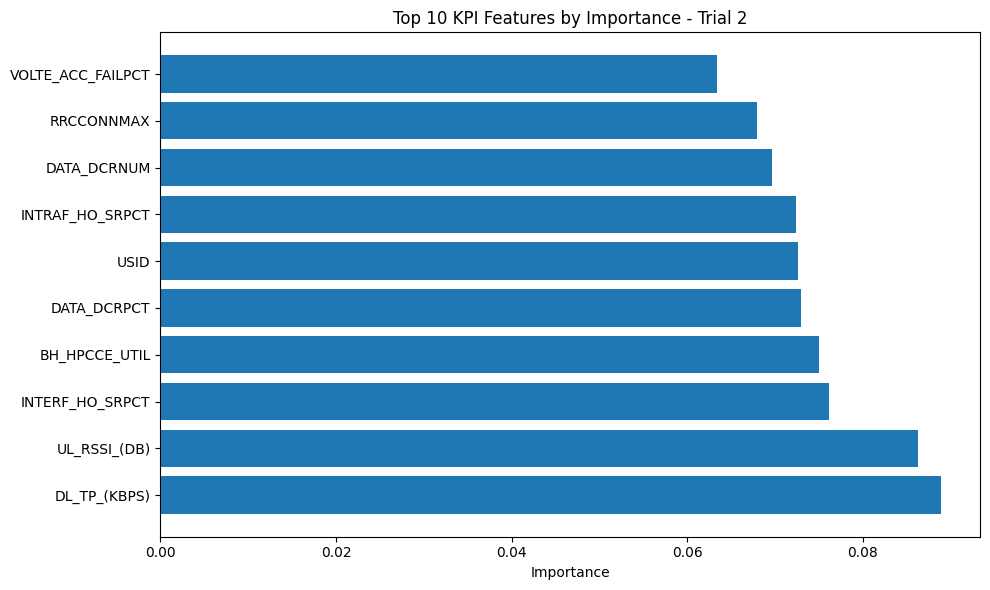


--- TRIAL 2 PREDICTION CONFIDENCE ---
Average confidence: 0.934
Min confidence: 0.550
Max confidence: 1.000
Low confidence predictions (<0.7): 4 out of 143


,Actual,Predicted,Confidence,Correct
36,(FO-RAN) HW - Replace,(FO-RAN) HW - Replace,0.670000,True
45,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.550246,True
49,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.550333,True
50,RAN Site Optimization (RAN),RAN Site Optimization (RAN),0.575500,True


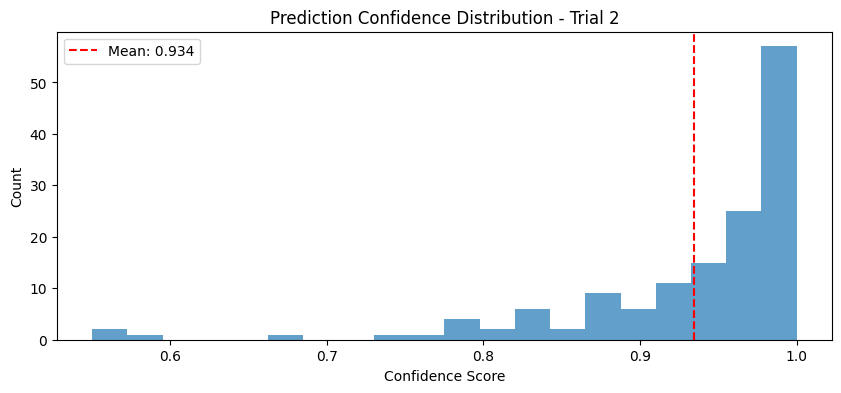

In [68]:
rf_classifier = best_model_2.named_steps['classifier']

importances = rf_classifier.feature_importances_
feature_names_2 = kpi_feature_cols

importance_df_2 = pd.DataFrame({
    'feature': feature_names_2,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n--- TRIAL 2 FEATURE IMPORTANCE (Random Forest) ---")
display(importance_df_2.head(10))

#
plt.figure(figsize=(10, 6))
plt.barh(importance_df_2['feature'].head(10), importance_df_2['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 KPI Features by Importance - Trial 2')
plt.tight_layout()
plt.show()

y2_pred_proba = best_model_2.predict_proba(X2_test)
y2_confidence = np.max(y2_pred_proba, axis=1)
y2_pred_classes = best_model_2.predict(X2_test)

confidence_df_2 = pd.DataFrame({
    'Actual': y2_test.values,
    'Predicted': y2_pred_classes,
    'Confidence': y2_confidence,
    'Correct': y2_test.values == y2_pred_classes
})

print("\n--- TRIAL 2 PREDICTION CONFIDENCE ---")
print(f"Average confidence: {y2_confidence.mean():.3f}")
print(f"Min confidence: {y2_confidence.min():.3f}")
print(f"Max confidence: {y2_confidence.max():.3f}")

low_conf_2 = confidence_df_2[confidence_df_2['Confidence'] < 0.7]
print(f"Low confidence predictions (<0.7): {len(low_conf_2)} out of {len(confidence_df_2)}")
display(low_conf_2.head(10))

plt.figure(figsize=(10, 4))
plt.hist(y2_confidence, bins=20, alpha=0.7)
plt.axvline(y2_confidence.mean(), color='red', linestyle='--', label=f'Mean: {y2_confidence.mean():.3f}')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution - Trial 2')
plt.legend()
plt.show()

SAVE TRIAL 2 FEATURE IMPORTANCE & CONFIDENCE

In [69]:

importance_df_2.to_csv(os.path.join(trial2_folder, "trial_2_feature_importance.csv"), index=False)

confidence_df_2.to_csv(os.path.join(trial2_folder, "trial_2_prediction_confidence.csv"), index=False)

confidence_summary_t2 = pd.DataFrame({
    'Metric': ['Mean Confidence', 'Min Confidence', 'Max Confidence', 'Low Confidence Count'],
    'Value': [
        y2_confidence.mean(),
        y2_confidence.min(),
        y2_confidence.max(),
        len(confidence_df_2[confidence_df_2['Confidence'] < 0.7])
    ]
})
confidence_summary_t2.to_csv(os.path.join(trial2_folder, "trial_2_confidence_summary.csv"), index=False)

plt.figure(figsize=(10, 4))
plt.hist(y2_confidence, bins=20, alpha=0.7)
plt.axvline(y2_confidence.mean(), color='red', linestyle='--', label=f'Mean: {y2_confidence.mean():.3f}')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution - Trial 2')
plt.legend()
plt.savefig(os.path.join(trial2_folder, "trial_2_confidence_distribution.png"), dpi=150, bbox_inches='tight')
plt.close()

print(f"Trial 2 feature importance and confidence results saved to: {trial2_folder}")

Trial 2 feature importance and confidence results saved to: /content/drive/MyDrive/26/model_trials/trial_2


# **TRIAL 3 — Multiple Models (Problem Group + KPI Combined)**


### **Objective**

- Combine `PROBLEM_DETAIL_(GROUP)` and the KPI measurements into a
single feature set.

- Compare several model families (Logistic Regression, Random
Forest, Gradient Boosting, SVM) on the same combined features to
see which algorithm performs best.

- The best-performing model becomes the candidate to move
forward with.


### **Research Question**

> Given both the problem group and KPI measurements, which model
> family best predicts `RESOLUTION_CATEGORY`?


### Build Combined Feature Set

In [70]:
trial3_base = tickets_df[["SITE_ID", problem_col, target_col]].copy()

trial3_df = trial3_base.merge(
    kpi_site_level,
    left_on="SITE_ID",
    right_on=kpi_merge_key,
    how="inner"
)

trial3_df = trial3_df.dropna(subset=[problem_col, target_col])

print("Trial 3 dataset shape:")
print(trial3_df.shape)

display(trial3_df.head())


Trial 3 dataset shape:
(713, 19)


,SITE_ID,PROBLEM_DETAIL_(GROUP),RESOLUTION_CATEGORY,SITE,USID,BH_HPCCE_UTIL,DL_TP_(KBPS),DL_VOLUME_(GBYTE),DATA_ACC_FAILPCT,DATA_DCRNUM,DATA_DCRPCT,VOLTE_ACC_FAILPCT,VOLTE_DCRPCT_(WORRE),VOLTE_DROPNUM_(WORRE),UL_RSSI_(DB),DUACNUM,INTERF_HO_SRPCT,INTRAF_HO_SRPCT,RRCCONNMAX
0,ABC00003,Dropped Call,RAN Site Optimization (RAN),ABC00003,80973.0,7.768519,7692.685185,11113.277778,0.546296,59.916667,0.268519,0.601852,0.388889,0.583333,-114.685185,0.000000,97.453704,98.861111,26.425926
1,ABC00024,Dropped Call,RAN Site Optimization (RAN),ABC00024,159420.0,6.139344,30214.777778,33353.753086,0.370370,218.672840,0.783951,0.322981,1.333333,5.283951,-117.382716,0.000000,87.080247,81.623457,55.049383
2,ABC00027,Dropped Call,RAN Site Optimization (RAN),ABC00027,139265.0,15.066667,14360.755556,81565.570370,0.170370,267.488889,0.277778,0.151852,0.348148,8.400000,-114.103704,0.166667,88.433333,98.100000,87.744444
3,ABC00075,Dropped Call,RAN Site Optimization (RAN),ABC00075,159057.0,11.172840,19366.851852,55167.493827,0.030864,272.870370,0.407407,0.030864,1.209877,11.475309,-116.401235,0.382716,89.604938,98.987654,82.364198
4,ABC00082,Dropped Call,RAN Site Optimization (RAN),ABC00082,128501.0,6.882353,15033.175000,4284.541667,1.000000,447.625000,2.375000,1.450000,14.125000,28.180556,-112.385714,0.000000,64.076923,85.825000,16.416667


In [71]:
exclude_cols_3 = ["SITE_ID", kpi_merge_key, problem_col, target_col]

kpi_feature_cols_3 = [
    c for c in trial3_df.columns
    if c not in exclude_cols_3
    and pd.api.types.is_numeric_dtype(trial3_df[c])
]

print("KPI feature columns:")
print(kpi_feature_cols_3)

print("\nCategorical feature columns:")
print([problem_col])


KPI feature columns:
['USID', 'BH_HPCCE_UTIL', 'DL_TP_(KBPS)', 'DL_VOLUME_(GBYTE)', 'DATA_ACC_FAILPCT', 'DATA_DCRNUM', 'DATA_DCRPCT', 'VOLTE_ACC_FAILPCT', 'VOLTE_DCRPCT_(WORRE)', 'VOLTE_DROPNUM_(WORRE)', 'UL_RSSI_(DB)', 'DUACNUM', 'INTERF_HO_SRPCT', 'INTRAF_HO_SRPCT', 'RRCCONNMAX']

Categorical feature columns:
['PROBLEM_DETAIL_(GROUP)']


### Train / Test Split (Group-Safe on SITE_ID)

In [72]:
X3 = trial3_df[[problem_col] + kpi_feature_cols_3].copy()
y3 = trial3_df[target_col].copy()
groups3 = trial3_df["SITE_ID"].copy()

gss3 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx3, test_idx3 = next(
    gss3.split(X3, y3, groups=groups3)
)

X3_train = X3.iloc[train_idx3].copy()
X3_test = X3.iloc[test_idx3].copy()
y3_train = y3.iloc[train_idx3].copy()
y3_test = y3.iloc[test_idx3].copy()

print("Training rows:", len(X3_train))
print("Testing rows:", len(X3_test))


Training rows: 574
Testing rows: 139


### Shared Preprocessor (Problem Group + KPI Measures)

In [73]:
from sklearn.preprocessing import StandardScaler

combined_preprocessor = ColumnTransformer(
    transformers=[
        (
            "problem",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            [problem_col]
        ),
        (
            "kpi",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            kpi_feature_cols_3
        )
    ]
)


### Define Candidate Models

In [74]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(
        random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=False,
        random_state=42
    )
}


### Train & Evaluate Each Model

In [75]:
trial3_results = []
trial3_fitted_models = {}

for model_name, estimator in candidate_models.items():
    pipeline = Pipeline([
        ("preprocessor", combined_preprocessor),
        ("classifier", estimator)
    ])

    pipeline.fit(X3_train, y3_train)
    preds = pipeline.predict(X3_test)

    trial3_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y3_test, preds),
        "Balanced Accuracy": balanced_accuracy_score(y3_test, preds),
        "Macro F1": f1_score(y3_test, preds, average="macro"),
        "Weighted F1": f1_score(y3_test, preds, average="weighted")
    })

    trial3_fitted_models[model_name] = pipeline

    print(f"{model_name} done.")

trial3_results_df = pd.DataFrame(trial3_results).set_index("Model")
display(trial3_results_df.round(3))


Logistic Regression done.
Random Forest done.
Gradient Boosting done.
SVM (RBF) done.


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
Model,,,,
Logistic Regression,0.914,0.278,0.294,0.887
Random Forest,0.914,0.250,0.262,0.893
Gradient Boosting,0.899,0.222,0.208,0.867
SVM (RBF),0.892,0.167,0.157,0.841


### Compare Models Visually

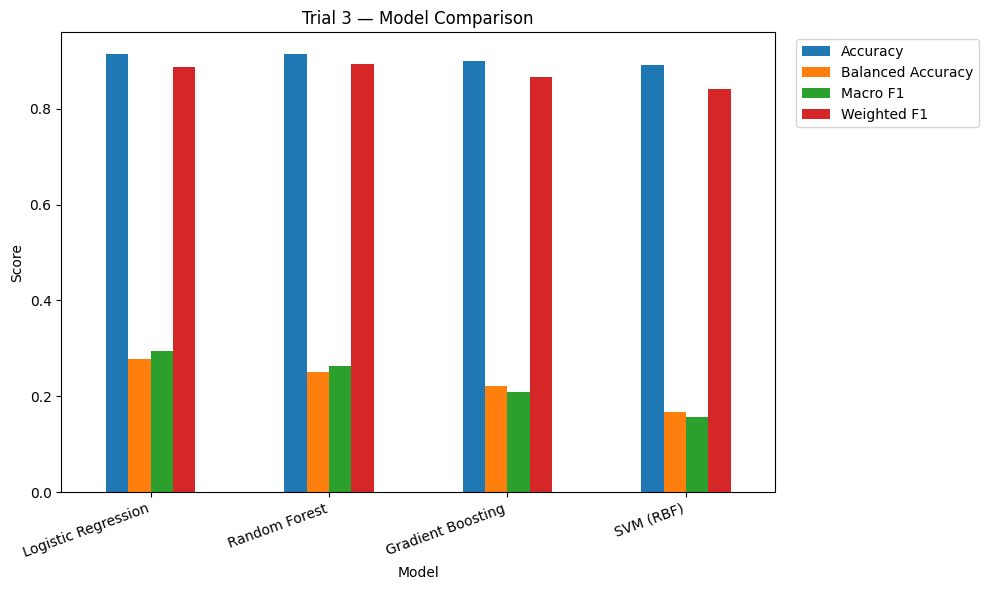

In [76]:
trial3_results_df[["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Trial 3 — Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


### Pick the Best Model

In [77]:
best_model_name = trial3_results_df["Balanced Accuracy"].idxmax()
best_model = trial3_fitted_models[best_model_name]

print("Best model by Balanced Accuracy:", best_model_name)
display(trial3_results_df.loc[[best_model_name]].round(3))


Best model by Balanced Accuracy: Logistic Regression


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
Model,,,,
Logistic Regression,0.914,0.278,0.294,0.887


In [78]:
best_preds = best_model.predict(X3_test)

print(
    classification_report(
        y3_test,
        best_preds,
        zero_division=0
    )
)


                                     precision    recall  f1-score   support

              (FO-RAN) HW - Replace       0.50      0.33      0.40         6
(FO-RAN) HW - Reseat/Physical Reset       0.50      0.33      0.40         3
     (FO-RAN) Maintenance / Project       0.00      0.00      0.00         2
        (RAN) Maintenance / Project       0.00      0.00      0.00         1
                   (RAN) SW - Reset       0.00      0.00      0.00         3
        RAN Site Optimization (RAN)       0.93      1.00      0.96       124

                           accuracy                           0.91       139
                          macro avg       0.32      0.28      0.29       139
                       weighted avg       0.86      0.91      0.89       139



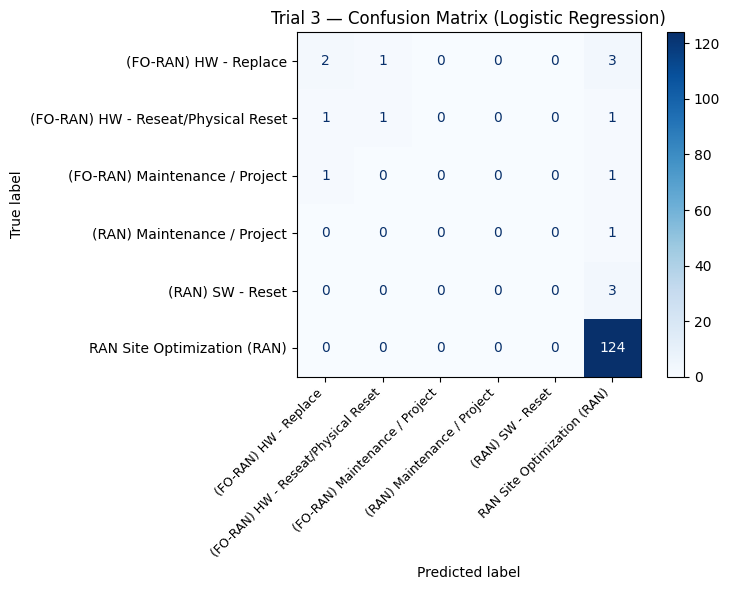

In [79]:
labels3 = sorted(y3.unique())

cm3 = confusion_matrix(
    y3_test,
    best_preds,
    labels=labels3
)

fig, ax = plt.subplots(figsize=(8, 6))

disp3 = ConfusionMatrixDisplay(
    confusion_matrix=cm3,
    display_labels=labels3
)

disp3.plot(ax=ax, cmap='Blues')

ax.set_xticklabels(labels3, rotation=45, ha="right", fontsize=9)

plt.title(f"Trial 3 — Confusion Matrix ({best_model_name})")

plt.tight_layout()
plt.show()


### Compare Against Trials 1 & 2

In [80]:
final_comparison = pd.DataFrame({
    "Trial 1 (Problem Only)": [
        trial1_accuracy, trial1_balanced_accuracy,
        trial1_macro_f1, trial1_weighted_f1
    ],
    "Trial 2 (KPI Only)": [
        trial2_accuracy, trial2_balanced_accuracy,
        trial2_macro_f1, trial2_weighted_f1
    ],
    f"Trial 3 ({best_model_name})": trial3_results_df.loc[best_model_name].tolist()
}, index=["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"])

display(final_comparison.round(3))


,Trial 1 (Problem Only),Trial 2 (KPI Only),Trial 3 (Logistic Regression)
Accuracy,0.727,0.909,0.914
Balanced Accuracy,0.383,0.222,0.278
Macro F1,0.312,0.242,0.294
Weighted F1,0.789,0.869,0.887


### Save Best Trial 3 Model

In [81]:
import os
import joblib

trial3_folder = "/content/drive/MyDrive/26/model_trials/trial_3"
os.makedirs(trial3_folder, exist_ok=True)

safe_name = best_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
model_path3 = os.path.join(
    trial3_folder,
    f"trial_3_{safe_name}_model.joblib"
)

joblib.dump(best_model, model_path3)

print("Trial 3 best model saved:")
print(model_path3)


Trial 3 best model saved:
/content/drive/MyDrive/26/model_trials/trial_3/trial_3_logistic_regression_model.joblib


FEATURE IMPORTANCE: TRIAL 3 (Logistic Regression)


--- TRIAL 3 FEATURE IMPORTANCE ---


,feature,coefficient,abs_coefficient
1,PROBLEM_DETAIL_(GROUP)_Dropped Call,-1.296005,1.296005
3,PROBLEM_DETAIL_(GROUP)_Link Failure,0.908662,0.908662
2,PROBLEM_DETAIL_(GROUP)_HW Fault,0.743643,0.743643
15,UL_RSSI_(DB),-0.710836,0.710836
17,INTERF_HO_SRPCT,0.696809,0.696809
0,PROBLEM_DETAIL_(GROUP)_Blocked Call,-0.559171,0.559171
9,DATA_ACC_FAILPCT,0.428922,0.428922
19,RRCCONNMAX,-0.427365,0.427365
18,INTRAF_HO_SRPCT,-0.418350,0.418350
4,PROBLEM_DETAIL_(GROUP)_SMART_SECTORS_OOS_ELTE,0.241270,0.241270


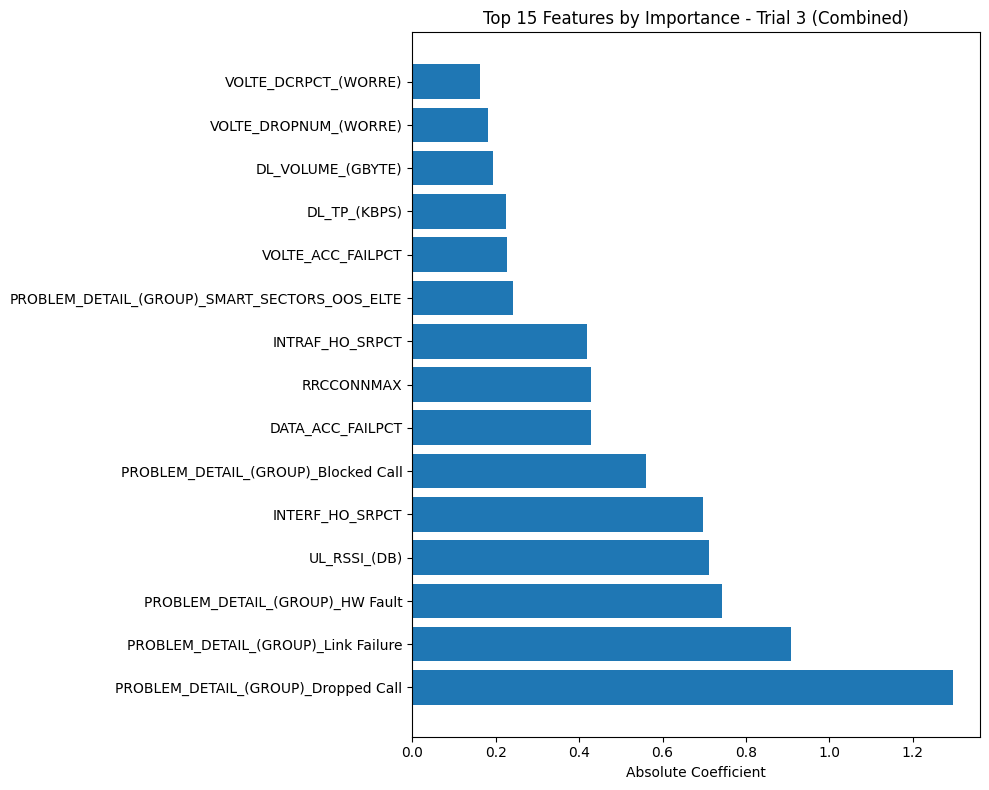


--- TRIAL 3 PREDICTION CONFIDENCE ---
Average confidence: 0.887
Min confidence: 0.317
Max confidence: 1.000
Low confidence predictions (<0.7): 12 out of 139


,Actual,Predicted,Confidence,Correct
20,(FO-RAN) HW - Replace,RAN Site Optimization (RAN),0.603096,False
21,(FO-RAN) HW - Replace,RAN Site Optimization (RAN),0.391616,False
59,(FO-RAN) HW - Replace,(FO-RAN) HW - Reseat/Physical Reset,0.646424,False
62,(FO-RAN) Maintenance / Project,(FO-RAN) HW - Replace,0.418093,False
65,(FO-RAN) HW - Reseat/Physical Reset,RAN Site Optimization (RAN),0.317356,False
68,(FO-RAN) HW - Reseat/Physical Reset,(FO-RAN) HW - Reseat/Physical Reset,0.427444,True
87,(FO-RAN) HW - Replace,(FO-RAN) HW - Replace,0.471938,True
88,(FO-RAN) HW - Replace,(FO-RAN) HW - Replace,0.471938,True
100,(FO-RAN) HW - Replace,RAN Site Optimization (RAN),0.406201,False
120,(RAN) Maintenance / Project,RAN Site Optimization (RAN),0.398228,False


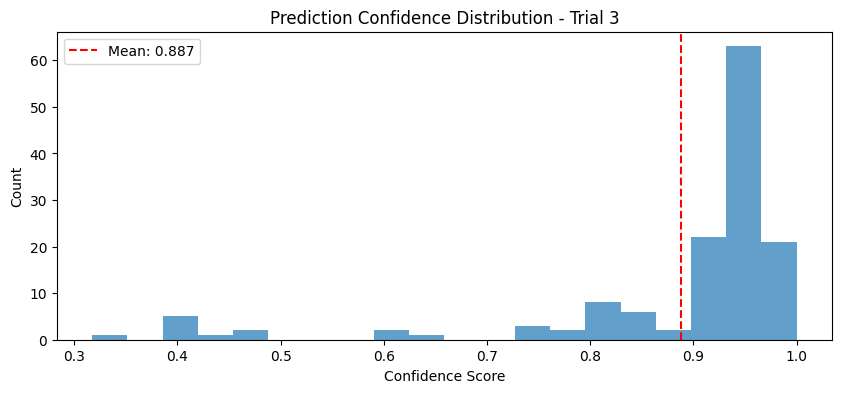

In [82]:

preprocessor_3 = best_model.named_steps['preprocessor']

onehot_encoder_3 = preprocessor_3.named_transformers_['problem'].named_steps['onehot']
problem_features = onehot_encoder_3.get_feature_names_out([problem_col])

kpi_features_3 = kpi_feature_cols_3

all_features_3 = list(problem_features) + kpi_features_3

classifier_3 = best_model.named_steps['classifier']
coef_3 = classifier_3.coef_[0]

importance_df_3 = pd.DataFrame({
    'feature': all_features_3,
    'coefficient': coef_3,
    'abs_coefficient': np.abs(coef_3)
}).sort_values('abs_coefficient', ascending=False)

print("\n--- TRIAL 3 FEATURE IMPORTANCE ---")
display(importance_df_3.head(15))

plt.figure(figsize=(10, 8))
top_features_3 = importance_df_3.head(15)
plt.barh(top_features_3['feature'], top_features_3['abs_coefficient'])
plt.xlabel('Absolute Coefficient')
plt.title('Top 15 Features by Importance - Trial 3 (Combined)')
plt.tight_layout()
plt.show()

y3_pred_proba = best_model.predict_proba(X3_test)
y3_confidence = np.max(y3_pred_proba, axis=1)
y3_pred_classes = best_model.predict(X3_test)

confidence_df_3 = pd.DataFrame({
    'Actual': y3_test.values,
    'Predicted': y3_pred_classes,
    'Confidence': y3_confidence,
    'Correct': y3_test.values == y3_pred_classes
})

print("\n--- TRIAL 3 PREDICTION CONFIDENCE ---")
print(f"Average confidence: {y3_confidence.mean():.3f}")
print(f"Min confidence: {y3_confidence.min():.3f}")
print(f"Max confidence: {y3_confidence.max():.3f}")

low_conf_3 = confidence_df_3[confidence_df_3['Confidence'] < 0.7]
print(f"Low confidence predictions (<0.7): {len(low_conf_3)} out of {len(confidence_df_3)}")
display(low_conf_3.head(10))

plt.figure(figsize=(10, 4))
plt.hist(y3_confidence, bins=20, alpha=0.7)
plt.axvline(y3_confidence.mean(), color='red', linestyle='--', label=f'Mean: {y3_confidence.mean():.3f}')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution - Trial 3')
plt.legend()
plt.show()

SAVE TRIAL 3 FEATURE IMPORTANCE & CONFIDENCE

In [83]:

importance_df_3.to_csv(os.path.join(trial3_folder, "trial_3_feature_importance.csv"), index=False)

confidence_df_3.to_csv(os.path.join(trial3_folder, "trial_3_prediction_confidence.csv"), index=False)

confidence_summary_t3 = pd.DataFrame({
    'Metric': ['Mean Confidence', 'Min Confidence', 'Max Confidence', 'Low Confidence Count'],
    'Value': [
        y3_confidence.mean(),
        y3_confidence.min(),
        y3_confidence.max(),
        len(confidence_df_3[confidence_df_3['Confidence'] < 0.7])
    ]
})
confidence_summary_t3.to_csv(os.path.join(trial3_folder, "trial_3_confidence_summary.csv"), index=False)

plt.figure(figsize=(10, 4))
plt.hist(y3_confidence, bins=20, alpha=0.7)
plt.axvline(y3_confidence.mean(), color='red', linestyle='--', label=f'Mean: {y3_confidence.mean():.3f}')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution - Trial 3')
plt.legend()
plt.savefig(os.path.join(trial3_folder, "trial_3_confidence_distribution.png"), dpi=150, bbox_inches='tight')
plt.close()

print(f"Trial 3 feature importance and confidence results saved to: {trial3_folder}")

Trial 3 feature importance and confidence results saved to: /content/drive/MyDrive/26/model_trials/trial_3


SUMMARY: COMPARE CONFIDENCE ACROSS TRIALS

In [84]:
confidence_summary = pd.DataFrame({
    'Trial 1 (Problem Only)': [
        confidence_scores.mean(),
        confidence_scores.min(),
        confidence_scores.max()
    ],
    'Trial 2 (KPI Only)': [
        y2_confidence.mean(),
        y2_confidence.min(),
        y2_confidence.max()
    ],
    'Trial 3 (Combined)': [
        y3_confidence.mean(),
        y3_confidence.min(),
        y3_confidence.max()
    ]
}, index=['Mean Confidence', 'Min Confidence', 'Max Confidence'])

print("\n--- CONFIDENCE COMPARISON ACROSS TRIALS ---")
display(confidence_summary.round(3))


print("\n--- TOP FEATURES ACROSS TRIALS ---")
print("\nTrial 1 (Problem only):")
display(importance_df.head(5))

print("\nTrial 2 (KPI only):")
display(importance_df_2.head(5))

print("\nTrial 3 (Combined):")
display(importance_df_3.head(5))


--- CONFIDENCE COMPARISON ACROSS TRIALS ---


,Trial 1 (Problem Only),Trial 2 (KPI Only),Trial 3 (Combined)
Mean Confidence,0.438,0.934,0.887
Min Confidence,0.289,0.550,0.317
Max Confidence,0.571,1.000,1.000



--- TOP FEATURES ACROSS TRIALS ---

Trial 1 (Problem only):


,feature,coefficient,abs_coefficient
1,PROBLEM_DETAIL_(GROUP)_Dropped Call,-2.061667,2.061667
4,PROBLEM_DETAIL_(GROUP)_SMART_SECTORS_OOS_ELTE,1.167044,1.167044
0,PROBLEM_DETAIL_(GROUP)_Blocked Call,-1.122462,1.122462
2,PROBLEM_DETAIL_(GROUP)_HW Fault,1.023320,1.023320
3,PROBLEM_DETAIL_(GROUP)_Link Failure,1.003468,1.003468



Trial 2 (KPI only):


,feature,importance
2,DL_TP_(KBPS),0.088891
10,UL_RSSI_(DB),0.086324
12,INTERF_HO_SRPCT,0.076136
1,BH_HPCCE_UTIL,0.075035
6,DATA_DCRPCT,0.072954



Trial 3 (Combined):


,feature,coefficient,abs_coefficient
1,PROBLEM_DETAIL_(GROUP)_Dropped Call,-1.296005,1.296005
3,PROBLEM_DETAIL_(GROUP)_Link Failure,0.908662,0.908662
2,PROBLEM_DETAIL_(GROUP)_HW Fault,0.743643,0.743643
15,UL_RSSI_(DB),-0.710836,0.710836
17,INTERF_HO_SRPCT,0.696809,0.696809
